In [12]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from catboost import CatBoostClassifier
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings('ignore')

from Data_polisher import DataPolish
from ModelTrainer import ModelTrainer
from Hypotheses import Hypothesis8, Hypothesis9, Hypothesis10

In [2]:
train = pd.read_csv('train_final_processed.csv')
test = pd.read_csv('test_final_processed.csv')

In [3]:
y = train['target']
X_raw = train.drop(columns=['target', 'sk_id_curr'])
X_test_raw = test.drop(columns=['sk_id_curr'])
test_ids = test['sk_id_curr']

In [4]:
def create_memory_friendly_polisher():
    return DataPolish(
        max_na_ratio=0.8,           
        low_variance_quantile=0.02, 
        corr_threshold=0.98,        
        handle_outliers=False,      
        outlier_method='clip',
        log_transform_skew=2.5,     
        scale_numeric=False,        
        random_state=42,
        verbose=False               
    )

In [7]:
def test_hypothesis_pipeline(hypothesis, hypothesis_name, X_train, X_test, y_train, test_ids):
    """
    Полный пайплайн тестирования одной гипотезы
    """
    
    #1: Применяем гипотезу
    X_with_hyp = hypothesis.fit_transform(X_train)
    X_test_with_hyp = hypothesis.transform(X_test)
    
    # Анализ новых фич
    new_features = [col for col in X_with_hyp.columns if col not in X_train.columns]
    print(f"   Добавлено {len(new_features)} новых фич")
    
    #2: Очистка данных
    polisher = create_memory_friendly_polisher()
    
    
    X_clean = polisher.fit_transform(X_with_hyp)
    X_test_clean = polisher.transform(X_test_with_hyp)

    # 3: Разделение данных
    X_tr, X_val, y_tr, y_val = train_test_split(
        X_clean, y_train, 
        test_size=0.2, 
        random_state=42, 
        stratify=y_train
    )

    # 4: Настройка модели
    categorical_columns = X_clean.select_dtypes(include=['object', 'category']).columns.tolist()    
    model = CatBoostClassifier(
        iterations=1000,
        learning_rate=0.05,
        depth=6,
        l2_leaf_reg=3,
        auto_class_weights='SqrtBalanced',
        random_state=42,
        verbose=False,
        early_stopping_rounds=100,
        eval_metric='AUC',
        cat_features=categorical_columns,
        thread_count=2
    )
    
    # 5: Обучение с ModelTrainer
    trainer = ModelTrainer(model, hypothesis_name)
    trainer.fit(X_tr, y_tr, X_val=X_val, y_val=y_val)
    
    # Шаг 6: Анализ результатов
    val_proba = trainer.model.predict_proba(X_val)[:, 1]
    
    # Графики
    trainer.plot_curves(y_val, val_proba)
    trainer.plot_importance(top_n=15)
    
    # Анализ важности фич
    feature_importance = trainer.model.get_feature_importance()
    importance_df = pd.DataFrame({
        'feature': X_clean.columns,
        'importance': feature_importance
    }).sort_values('importance', ascending=False)
    
    # Анализ новых фич в топе
    new_features_in_top = importance_df[importance_df['feature'].isin(new_features)]
    if not new_features_in_top.empty:
        for idx, row in new_features_in_top.head(5).iterrows():
            rank = importance_df.index.get_loc(idx) + 1
            print(f"   #{rank:2d}: {row['feature']} - {row['importance']:.4f}")
    else:
        print(" Новые фичи не вошли в топ")
    
    #7: Создание сабмита
    test_proba, test_pred = trainer.predict_test(X_test_clean)
    trainer.make_submission(test_ids, test_proba)
    
    return {
        'hypothesis_name': hypothesis_name,
        'val_auc': trainer.val_auc,
        'train_auc': trainer.train_auc,
        'pr_auc': trainer.pr_auc,
        'accuracy': trainer.accuracy,
        'precision': trainer.precision,
        'recall': trainer.recall,
        'f1': trainer.f1,
        'best_threshold': trainer.best_threshold,
        'new_features': new_features,
        'new_features_count': len(new_features),
        'importance_df': importance_df,
        'trainer': trainer,
        'submission_file': f"results/submission_{hypothesis_name}.csv"
    }


   Добавлено 7 новых фич
Модель: CatBoostClassifier
0:	test: 0.7019401	best: 0.7019401 (0)	total: 1.26s	remaining: 20m 58s
100:	test: 0.7691540	best: 0.7691540 (100)	total: 1m 41s	remaining: 15m 7s
200:	test: 0.7768814	best: 0.7768814 (200)	total: 3m 18s	remaining: 13m 9s
300:	test: 0.7813659	best: 0.7813659 (300)	total: 4m 58s	remaining: 11m 33s
400:	test: 0.7841178	best: 0.7841178 (400)	total: 6m 52s	remaining: 10m 15s
500:	test: 0.7854877	best: 0.7855192 (496)	total: 8m 29s	remaining: 8m 27s
600:	test: 0.7861029	best: 0.7862163 (584)	total: 10m 11s	remaining: 6m 45s
700:	test: 0.7866241	best: 0.7866336 (697)	total: 11m 46s	remaining: 5m 1s
800:	test: 0.7869603	best: 0.7869844 (797)	total: 13m 21s	remaining: 3m 19s
900:	test: 0.7870655	best: 0.7871046 (897)	total: 15m 1s	remaining: 1m 39s
999:	test: 0.7872891	best: 0.7873623 (957)	total: 16m 32s	remaining: 0us

bestTest = 0.787362334
bestIteration = 957

Shrink model to first 958 iterations.
РЕЗУЛЬТАТЫ — Hypothesis8_Installments
Val 

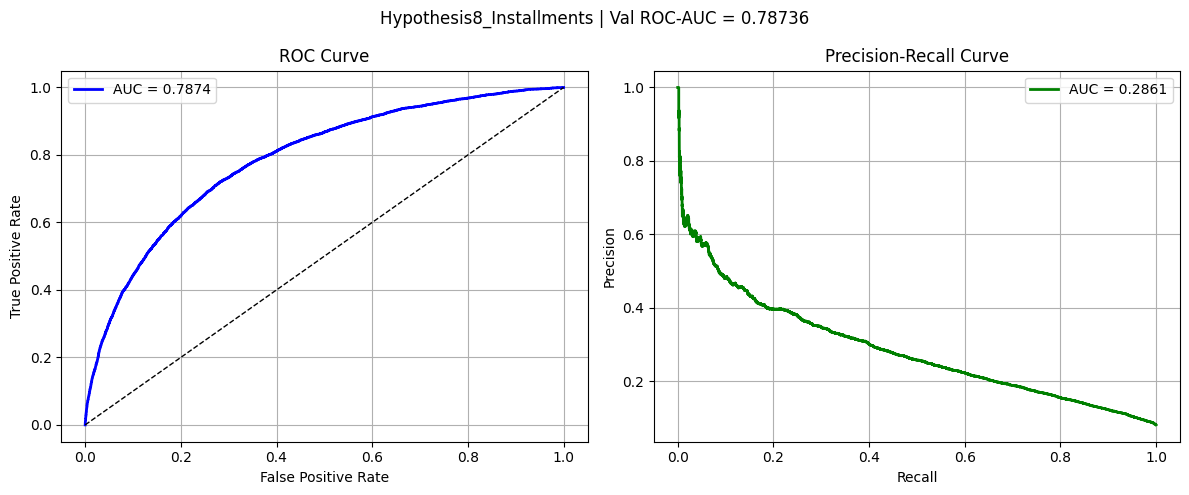

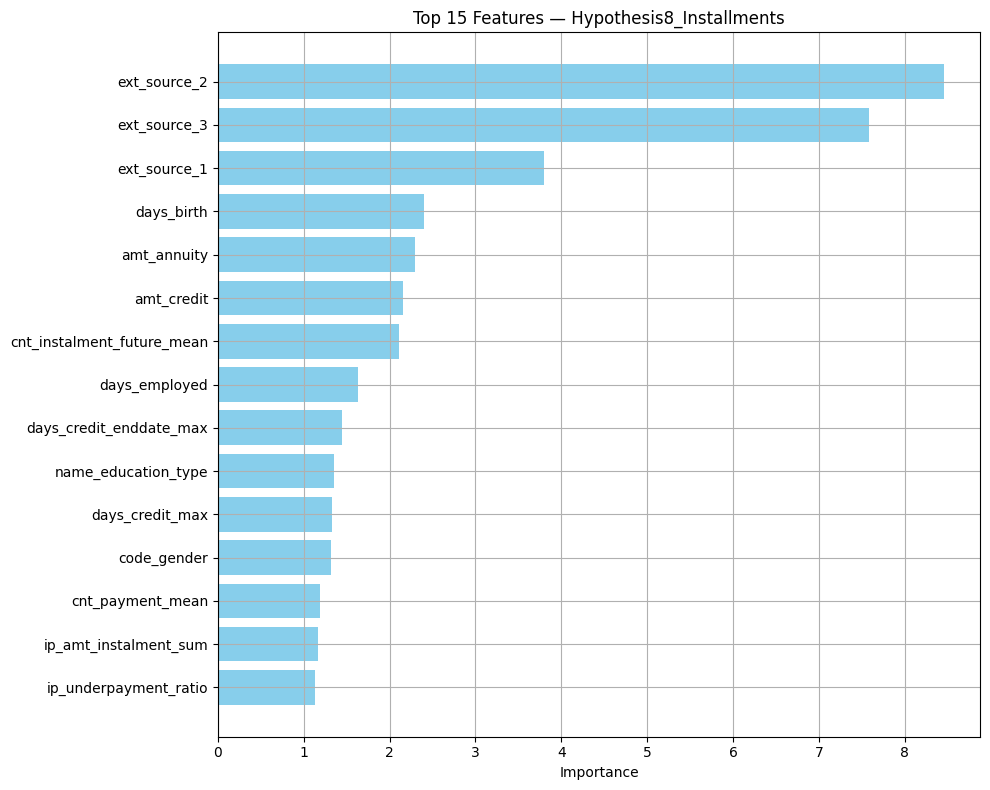

   #15: ip_underpayment_ratio - 1.1284
   #18: ip_max_delay - 0.8455
   #21: ip_underpayment_total - 0.8032
   #44: ip_paid_ratio - 0.5224
   #237: ip_version_diversity - 0.0562


In [8]:
results = []

hyp8 = Hypothesis8()
result8 = test_hypothesis_pipeline(hyp8, "Hypothesis8_Installments", X_raw, X_test_raw, y, test_ids)
results.append(result8)

   Добавлено 7 новых фич
Модель: CatBoostClassifier
0:	test: 0.7057438	best: 0.7057438 (0)	total: 2.95s	remaining: 49m 4s
100:	test: 0.7658308	best: 0.7658308 (100)	total: 1m 42s	remaining: 15m 23s
200:	test: 0.7743233	best: 0.7743233 (200)	total: 3m 23s	remaining: 13m 32s
300:	test: 0.7795042	best: 0.7795042 (300)	total: 5m	remaining: 11m 40s
400:	test: 0.7823228	best: 0.7823228 (400)	total: 6m 38s	remaining: 9m 57s
500:	test: 0.7838202	best: 0.7838342 (499)	total: 8m 17s	remaining: 8m 16s
600:	test: 0.7848120	best: 0.7848120 (600)	total: 10m 15s	remaining: 6m 50s
700:	test: 0.7852990	best: 0.7853092 (699)	total: 12m	remaining: 5m 8s
800:	test: 0.7855885	best: 0.7856303 (782)	total: 13m 41s	remaining: 3m 24s
900:	test: 0.7857589	best: 0.7858158 (867)	total: 15m 44s	remaining: 1m 44s
999:	test: 0.7856480	best: 0.7858577 (963)	total: 17m 23s	remaining: 0us

bestTest = 0.7858577199
bestIteration = 963

Shrink model to first 964 iterations.
РЕЗУЛЬТАТЫ — Hypothesis9_Installments
Val ROC-AU

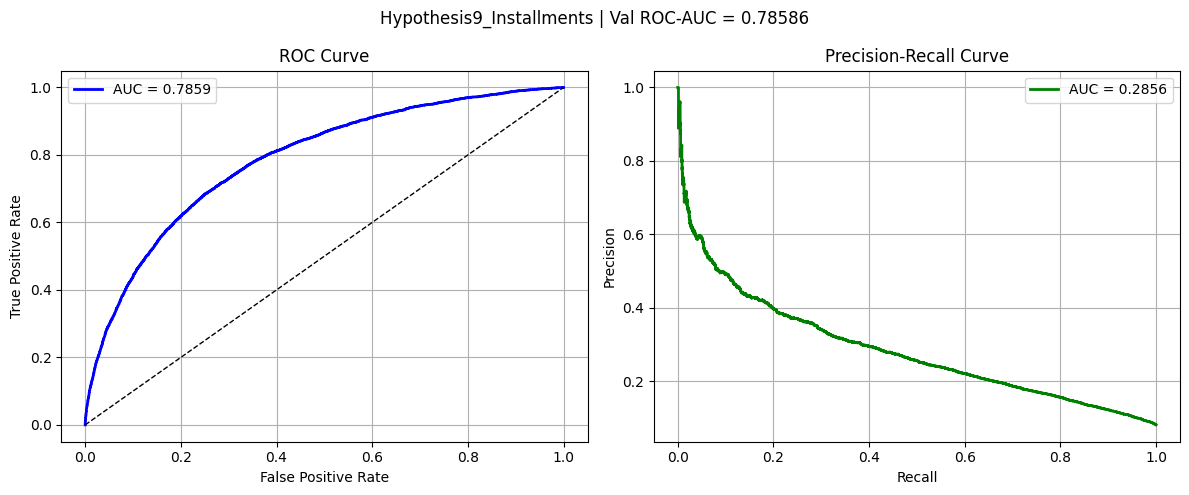

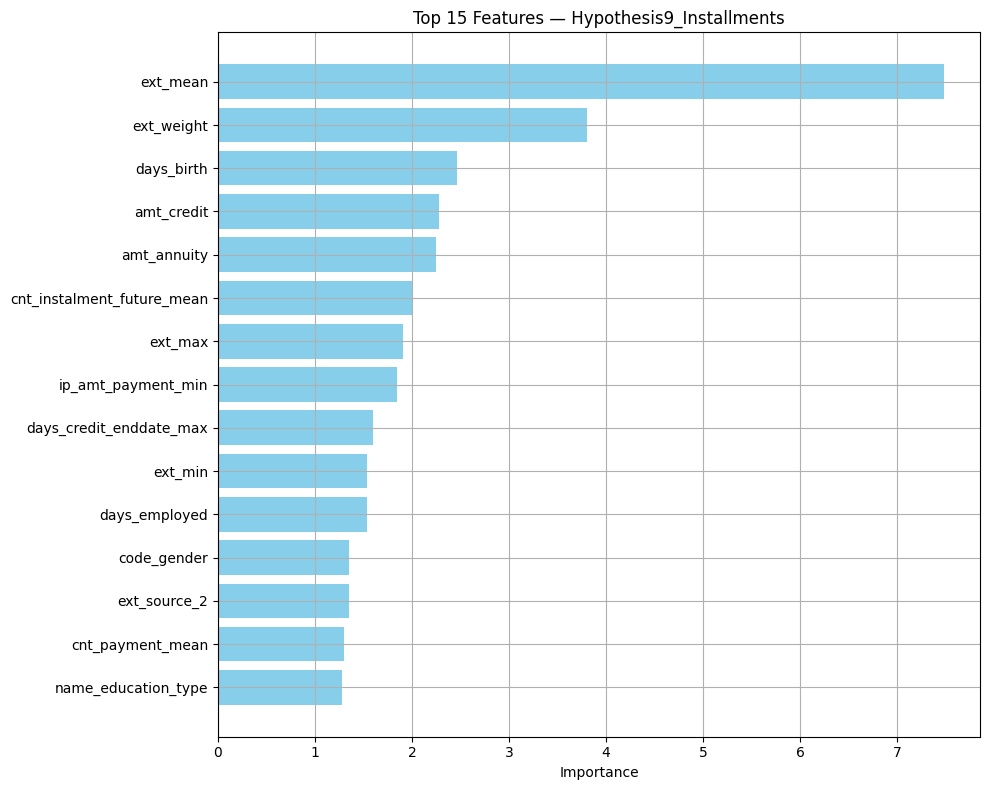

   # 1: ext_mean - 7.4789
   # 2: ext_weight - 3.8078
   # 7: ext_max - 1.9050
   #10: ext_min - 1.5360
   #101: ext_std - 0.2569


In [9]:
hyp9 = Hypothesis9()
result9 = test_hypothesis_pipeline(hyp9, "Hypothesis9_Installments", X_raw, X_test_raw, y, test_ids)
results.append(result9)

   Добавлено 12 новых фич
Модель: CatBoostClassifier
0:	test: 0.6938453	best: 0.6938453 (0)	total: 2.97s	remaining: 49m 30s
100:	test: 0.7722041	best: 0.7722041 (100)	total: 2m 46s	remaining: 24m 44s
200:	test: 0.7802252	best: 0.7802252 (200)	total: 4m 51s	remaining: 19m 19s
300:	test: 0.7848940	best: 0.7848940 (300)	total: 7m 42s	remaining: 17m 53s
400:	test: 0.7876821	best: 0.7876821 (400)	total: 9m 35s	remaining: 14m 20s
500:	test: 0.7889290	best: 0.7889482 (499)	total: 11m 44s	remaining: 11m 42s
600:	test: 0.7897362	best: 0.7897508 (599)	total: 13m 42s	remaining: 9m 5s
700:	test: 0.7902818	best: 0.7902941 (699)	total: 15m 38s	remaining: 6m 40s
800:	test: 0.7906059	best: 0.7906118 (791)	total: 17m 31s	remaining: 4m 21s
900:	test: 0.7905568	best: 0.7906895 (823)	total: 20m 25s	remaining: 2m 14s
999:	test: 0.7908274	best: 0.7908989 (977)	total: 22m 39s	remaining: 0us

bestTest = 0.7908989478
bestIteration = 977

Shrink model to first 978 iterations.
РЕЗУЛЬТАТЫ — Hypothesis10_Installme

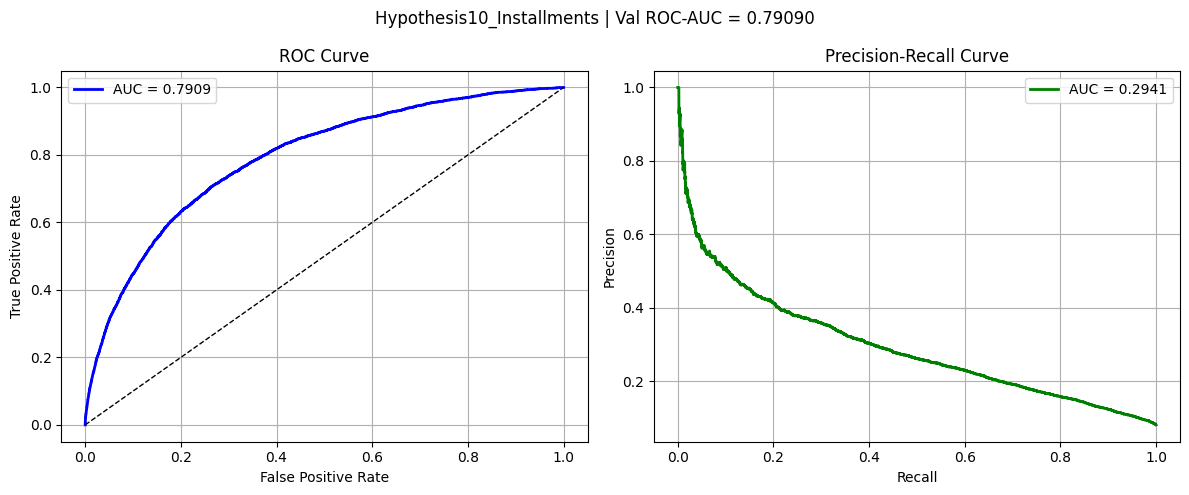

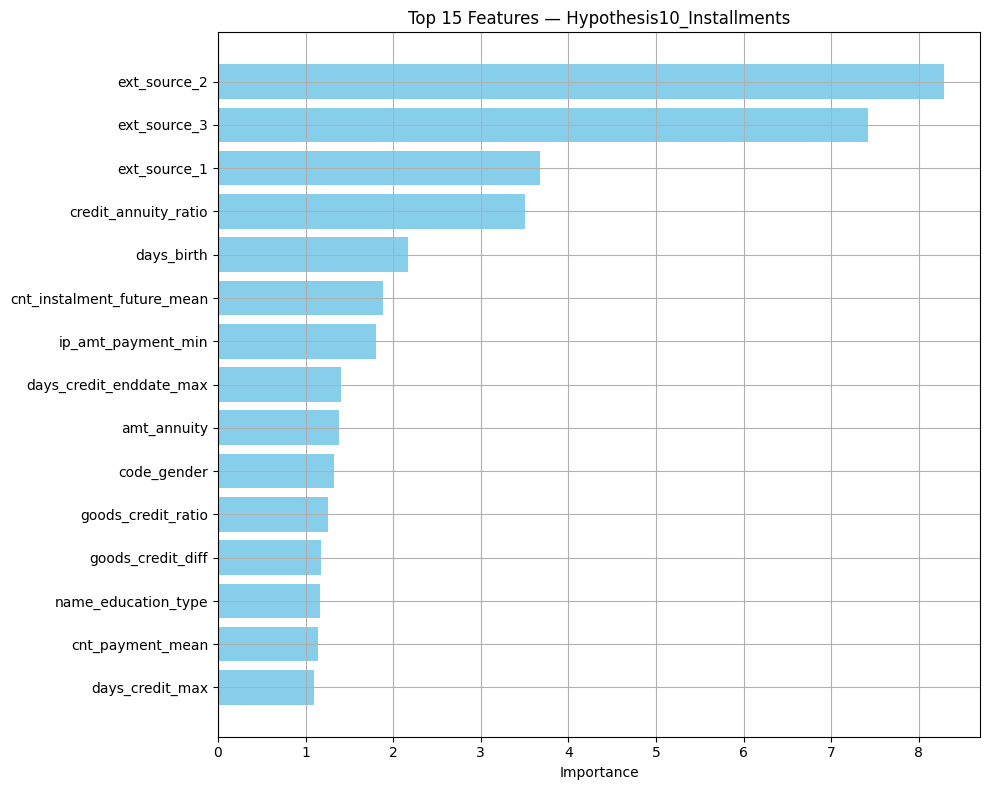

   # 4: credit_annuity_ratio - 3.5098
   #11: goods_credit_ratio - 1.2527
   #12: goods_credit_diff - 1.1786
   #25: annuity_income_ratio - 0.7103
   #28: employment_years - 0.6796


In [11]:
hyp10 = Hypothesis10()
result10 = test_hypothesis_pipeline(hyp10, "Hypothesis10_Installments", X_raw, X_test_raw, y, test_ids)
results.append(result10)

   Добавлено 26 новых фич
Модель: CatBoostClassifier
0:	test: 0.7017205	best: 0.7017205 (0)	total: 2.1s	remaining: 34m 55s
100:	test: 0.7717098	best: 0.7717098 (100)	total: 3m 24s	remaining: 30m 17s
200:	test: 0.7802418	best: 0.7802418 (200)	total: 6m 55s	remaining: 27m 31s
300:	test: 0.7849060	best: 0.7849060 (300)	total: 10m 26s	remaining: 24m 15s
400:	test: 0.7873786	best: 0.7873786 (400)	total: 13m 52s	remaining: 20m 43s
500:	test: 0.7886729	best: 0.7886729 (500)	total: 17m 13s	remaining: 17m 9s
600:	test: 0.7893348	best: 0.7893348 (600)	total: 20m 45s	remaining: 13m 46s
700:	test: 0.7899295	best: 0.7899295 (700)	total: 22m 52s	remaining: 9m 45s
800:	test: 0.7901014	best: 0.7901962 (787)	total: 24m 44s	remaining: 6m 8s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.7901962042
bestIteration = 787

Shrink model to first 788 iterations.
РЕЗУЛЬТАТЫ — comb_hyp
Val ROC-AUC       : 0.79020
Val PR-AUC        : 0.29034
Train ROC-AUC     : 0.83567
Лучший порог      : 0.

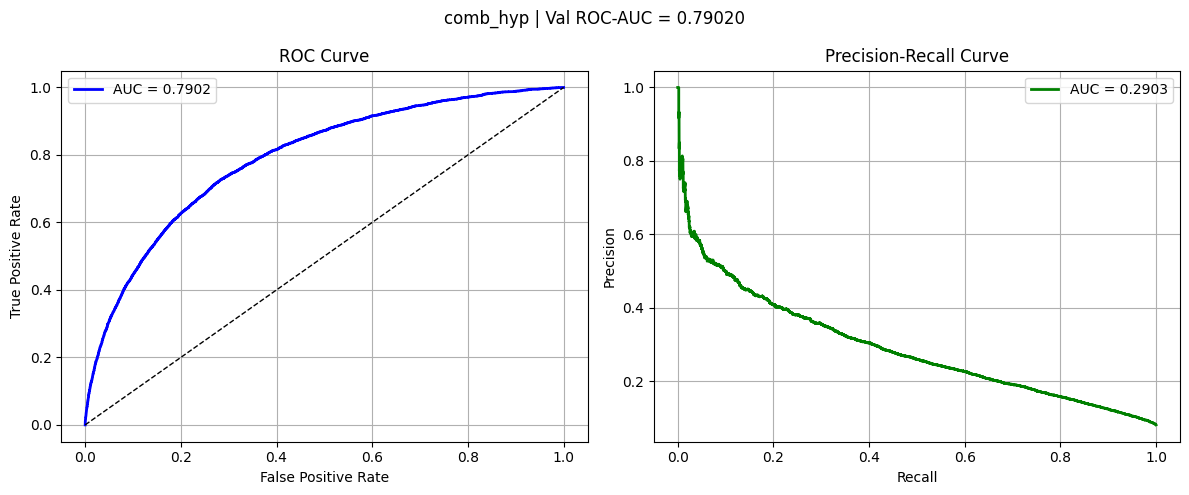

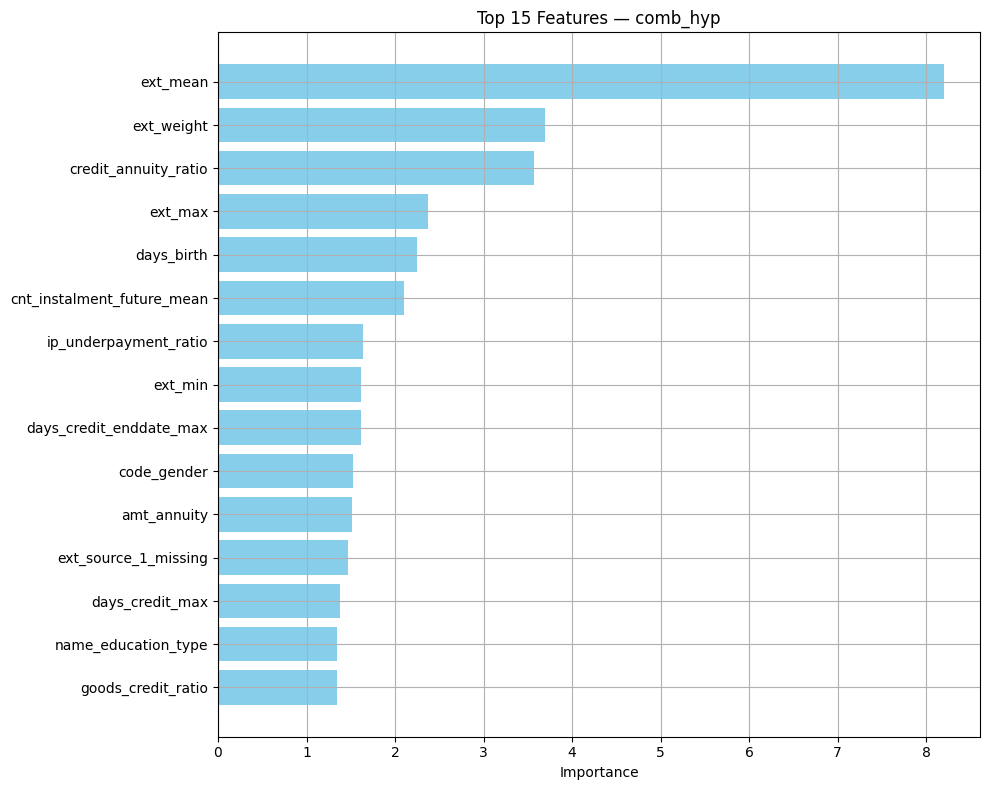

   # 1: ext_mean - 8.1977
   # 2: ext_weight - 3.6890
   # 3: credit_annuity_ratio - 3.5659
   # 4: ext_max - 2.3689
   # 7: ip_underpayment_ratio - 1.6430


In [13]:
hyp_pipline = Pipeline([
    ('hypothesis8', Hypothesis8()),
    ('hypothesis9', Hypothesis9()),
    ('hypothesis10', Hypothesis10()),
])

comb_result = test_hypothesis_pipeline(hyp_pipline, 'comb_hyp', X_raw, X_test_raw, y, test_ids)
results.append(comb_result)
